In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ADHD_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\ADHD2022\ADHD2022_iPSYCH_deCODE_PGC\ADHD2022.tsv"  
ASD_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\14671989\iPSYCH-PGC_ASD_Nov2017\ASD2019.tsv"
Dyslexia_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\Dyslexia_GWAS_Summary_Statistics_for_top_10K_SNPs\top_10K_variants.txt"


In [3]:
ADHD_df = pd.read_csv(
    ADHD_file_path,
    delim_whitespace=True,
    low_memory=False
)

ASD_df = pd.read_csv(
    ASD_file_path,
    delim_whitespace=True,
    low_memory=False
)

dys_df = pd.read_csv(
    Dyslexia_file_path, 
    sep="\t", 
    low_memory=False)

C:\Users\tharu\AppData\Local\Temp\ipykernel_25728\1698581988.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ADHD_df = pd.read_csv(
C:\Users\tharu\AppData\Local\Temp\ipykernel_25728\1698581988.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ASD_df = pd.read_csv(


In [4]:
ADHD_df.head()

,CHR,SNP,BP,A1,A2,FRQ_A_38691,FRQ_U_186843,INFO,OR,SE,P,Direction,Nca,Nco
0,8,rs62513865,101592213,C,T,0.925,0.937,0.981,0.99631,0.0175,0.8325,+---+++0-++-+,38691,186843
1,8,rs79643588,106973048,G,A,0.910,0.917,1.000,1.00411,0.0159,0.7967,++--++-+-+-++,38691,186843
2,8,rs17396518,108690829,T,G,0.561,0.577,0.998,0.99611,0.0096,0.6876,--++-++??-+--,37367,184388
3,8,rs983166,108681675,A,C,0.570,0.586,0.996,0.99491,0.0096,0.5956,--++-++++-+--,38691,186843
4,8,rs28842593,103044620,T,C,0.839,0.836,0.982,0.98314,0.0135,0.2081,----++0+??--+,37504,184525


In [5]:
ASD_df.head()

,CHR,SNP,BP,A1,A2,INFO,OR,SE,P
0,8,rs62513865,101592213,T,C,0.949,1.00652,0.0270,0.808600
1,8,rs79643588,106973048,A,G,0.997,1.01786,0.0240,0.460600
2,8,rs17396518,108690829,T,G,0.987,0.96127,0.0140,0.004647
3,8,rs983166,108681675,A,C,0.998,0.97990,0.0139,0.145200
4,8,rs28842593,103044620,T,C,0.857,0.99591,0.0203,0.841500


In [6]:
dys_df.head()

,assay.name,scaffold,position,effect_allele,other_allele,effect,stderr,pvalue,avg.rsqr
0,rs13082684,chr3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,chr3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,chr3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,chr3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,chr3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492


In [7]:
n = 5  # number of values to inspect per column

for col in ADHD_df.columns:
    print(f"\nColumn: {col}")
    print(ADHD_df[col].head(n).to_list())



Column: CHR
[8, 8, 8, 8, 8]

Column: SNP
['rs62513865', 'rs79643588', 'rs17396518', 'rs983166', 'rs28842593']

Column: BP
[101592213, 106973048, 108690829, 108681675, 103044620]

Column: A1
['C', 'G', 'T', 'A', 'T']

Column: A2
['T', 'A', 'G', 'C', 'C']

Column: FRQ_A_38691
[0.925, 0.91, 0.561, 0.57, 0.839]

Column: FRQ_U_186843
[0.937, 0.917, 0.577, 0.586, 0.836]

Column: INFO
[0.981, 1.0, 0.998, 0.996, 0.982]

Column: OR
[0.99631, 1.00411, 0.99611, 0.99491, 0.98314]

Column: SE
[0.0175, 0.0159, 0.0096, 0.0096, 0.0135]

Column: P
[0.8325, 0.7967, 0.6876, 0.5956, 0.2081]

Column: Direction
['+---+++0-++-+', '++--++-+-+-++', '--++-++??-+--', '--++-++++-+--', '----++0+??--+']

Column: Nca
[38691, 38691, 37367, 38691, 37504]

Column: Nco
[186843, 186843, 184388, 186843, 184525]


In [8]:
n = 5  # number of values to inspect per column

for col in ASD_df.columns:
    print(f"\nColumn: {col}")
    print(ADHD_df[col].head(n).to_list())



Column: CHR
[8, 8, 8, 8, 8]

Column: SNP
['rs62513865', 'rs79643588', 'rs17396518', 'rs983166', 'rs28842593']

Column: BP
[101592213, 106973048, 108690829, 108681675, 103044620]

Column: A1
['C', 'G', 'T', 'A', 'T']

Column: A2
['T', 'A', 'G', 'C', 'C']

Column: INFO
[0.981, 1.0, 0.998, 0.996, 0.982]

Column: OR
[0.99631, 1.00411, 0.99611, 0.99491, 0.98314]

Column: SE
[0.0175, 0.0159, 0.0096, 0.0096, 0.0135]

Column: P
[0.8325, 0.7967, 0.6876, 0.5956, 0.2081]


In [9]:
n = 5  # number of values to inspect per column

for col in dys_df.columns:
    print(f"\nColumn: {col}")
    print(dys_df[col].head(n).to_list())



Column: assay.name
['rs13082684', 'rs7628848', 'rs10048942', 'rs28509770', 'rs28576629']

Column: scaffold
['chr3', 'chr3', 'chr3', 'chr3', 'chr3']

Column: position
[135783166, 135781940, 135785491, 135793657, 135773661]

Column: effect_allele
['G', 'G', 'G', 'G', 'T']

Column: other_allele
['A', 'A', 'A', 'C', 'G']

Column: effect
[-0.0667863617594715, -0.0666284214337651, 0.0665788559688778, 0.0657198142549327, 0.066345111895225]

Column: stderr
[0.008005134111557, 0.008000477687492, 0.0080039638069562, 0.0079368881330161, 0.0080096777390211]

Column: pvalue
[1.02885250871639e-16, 1.16380110142833e-16, 1.26316637374567e-16, 1.69038682912248e-16, 1.6915792743937099e-16]

Column: avg.rsqr
[0.989839136600494, 0.989948153495789, 0.989762485027313, 0.972897887229919, 0.989492356777191]


In [10]:
ADHD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6774224 entries, 0 to 6774223
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   CHR           int64  
 1   SNP           object 
 2   BP            int64  
 3   A1            object 
 4   A2            object 
 5   FRQ_A_38691   float64
 6   FRQ_U_186843  float64
 7   INFO          float64
 8   OR            float64
 9   SE            float64
 10  P             float64
 11  Direction     object 
 12  Nca           int64  
 13  Nco           int64  
dtypes: float64(6), int64(4), object(4)
memory usage: 723.6+ MB


In [11]:
ASD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9112386 entries, 0 to 9112385
Data columns (total 9 columns):
 #   Column  Dtype  
---  ------  -----  
 0   CHR     int64  
 1   SNP     object 
 2   BP      int64  
 3   A1      object 
 4   A2      object 
 5   INFO    float64
 6   OR      float64
 7   SE      float64
 8   P       float64
dtypes: float64(4), int64(2), object(3)
memory usage: 625.7+ MB


In [12]:
dys_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   assay.name     10000 non-null  object 
 1   scaffold       10000 non-null  object 
 2   position       10000 non-null  int64  
 3   effect_allele  10000 non-null  object 
 4   other_allele   10000 non-null  object 
 5   effect         10000 non-null  float64
 6   stderr         10000 non-null  float64
 7   pvalue         10000 non-null  float64
 8   avg.rsqr       10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB


 | Column           | Meaning                                                |
 | ---------------- | ------------------------------------------------------ |
 | **CHR**          | Chromosome number                                      |
 | **SNP**          | rsID                                                   |
 | **BP**           | Base-pair position (hg19 / hg38                        |
 | **A1**           | Effect allele                                          |
 | **A2**           | Other allele                                           |
 | **FRQ_A_38691**  | Effect allele frequency in cases                       |
 | **FRQ_U_186843** | Effect allele frequency in controls                    |
 | **INFO**         | Imputation quality (keep ≥ 0.8)                        |
 | **OR**           | Odds ratio (logistic GWAS)                             |
 | **SE**           | Standard error                                         |
 | **P**            | P-value                                                |
 | **Direction**    | Per-cohort effect direction                            |
 | **Nca**          | Number of cases                                        |
 | **Nco**          | Number of controls                                     |


### Rename Columns to match each dataset

In [13]:
# Rename columns
ADHD_df = ADHD_df.rename(columns={
    "CHR": "CHR",
    "BP": "BP",
    "SNP": "SNP",
    "A1": "A1",
    "A2": "A2",
    "OR": "OR",
    "SE": "SE",
    "P": "P"
})

# Keep only required columns
ADHD_df = ADHD_df[["CHR", "BP", "SNP", "A1", "A2", "OR", "SE", "P"]]
ASD_df = ASD_df[["CHR", "BP", "SNP", "A1", "A2", "OR", "SE", "P"]]


In [14]:
dys_df.rename(columns={
    "assay.name": "SNP",
    "scaffold": "CHR",
    "position": "BP",
    "effect_allele": "A1",
    "other_allele": "A2",
    "effect": "BETA",
    "stderr": "SE",
    "pvalue": "P",
    "avg.rsqr": "INFO"
}, inplace=True)

def chr_to_int(chr_val):
    chr_val = str(chr_val).replace("chr", "")  # remove "chr" prefix
    if chr_val.isdigit():
        return int(chr_val)
    elif chr_val.upper() == "X":
        return 23
    elif chr_val.upper() == "Y":
        return 24
    else:
        return np.nan  # for MT or unknown

dys_df["CHR"] = dys_df["CHR"].apply(chr_to_int)
dys_df = dys_df.dropna(subset=["CHR"])  # drop non-autosomes/unknown chromosomes
dys_df["CHR"] = dys_df["CHR"].astype(int)


In [15]:
ADHD_df

,CHR,BP,SNP,A1,A2,OR,SE,P
0,8,101592213,rs62513865,C,T,0.99631,0.0175,0.8325
1,8,106973048,rs79643588,G,A,1.00411,0.0159,0.7967
2,8,108690829,rs17396518,T,G,0.99611,0.0096,0.6876
3,8,108681675,rs983166,A,C,0.99491,0.0096,0.5956
4,8,103044620,rs28842593,T,C,0.98314,0.0135,0.2081
...,...,...,...,...,...,...,...,...
6774219,20,44372620,rs2425746,T,C,1.01369,0.0096,0.1555
6774220,20,49004040,rs6067431,C,T,0.99442,0.0099,0.5696
6774221,20,40403831,rs1475049,G,A,0.96262,0.0300,0.2043
6774222,20,46761380,rs117705259,G,A,1.03490,0.0468,0.4637


In [16]:
ASD_df

,CHR,BP,SNP,A1,A2,OR,SE,P
0,8,101592213,rs62513865,T,C,1.00652,0.0270,0.808600
1,8,106973048,rs79643588,A,G,1.01786,0.0240,0.460600
2,8,108690829,rs17396518,T,G,0.96127,0.0140,0.004647
3,8,108681675,rs983166,A,C,0.97990,0.0139,0.145200
4,8,103044620,rs28842593,T,C,0.99591,0.0203,0.841500
...,...,...,...,...,...,...,...,...
9112381,20,43203203,rs200365683,T,TTTTTTG,0.98167,0.0322,0.565600
9112382,20,49004040,rs6067431,T,C,0.99432,0.0147,0.696700
9112383,20,40403831,rs1475049,A,G,1.08709,0.0410,0.041630
9112384,20,46761380,rs117705259,A,G,0.94847,0.0587,0.368000


In [17]:
dys_df

,SNP,CHR,BP,A1,A2,BETA,SE,P,INFO
0,rs13082684,3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492
...,...,...,...,...,...,...,...,...,...
9995,rs1011372,7,91509867,T,C,-0.033586,0.006948,1.337714e-06,0.993477
9996,rs7631908,3,49425707,T,G,-0.033788,0.006985,1.337743e-06,0.996688
9997,rs4723841,7,39329539,G,A,-0.033504,0.006932,1.338003e-06,0.993595
9998,rs2043018,2,198236958,G,A,-0.036308,0.007526,1.338356e-06,0.971689


### Convert OR to BETA

In [18]:
# For ADHD
if "OR" in ADHD_df.columns:
    ADHD_df["BETA"] = np.log(ADHD_df["OR"])
else:
    print("No OR column found in ADHD_df!")

# For ASD
if "OR" in ASD_df.columns:
    ASD_df["BETA"] = np.log(ASD_df["OR"])
else:
    print("No OR column found in ASD_df!")

In [19]:
ADHD_df

,CHR,BP,SNP,A1,A2,OR,SE,P,BETA
0,8,101592213,rs62513865,C,T,0.99631,0.0175,0.8325,-0.003697
1,8,106973048,rs79643588,G,A,1.00411,0.0159,0.7967,0.004102
2,8,108690829,rs17396518,T,G,0.99611,0.0096,0.6876,-0.003898
3,8,108681675,rs983166,A,C,0.99491,0.0096,0.5956,-0.005103
4,8,103044620,rs28842593,T,C,0.98314,0.0135,0.2081,-0.017004
...,...,...,...,...,...,...,...,...,...
6774219,20,44372620,rs2425746,T,C,1.01369,0.0096,0.1555,0.013597
6774220,20,49004040,rs6067431,C,T,0.99442,0.0099,0.5696,-0.005596
6774221,20,40403831,rs1475049,G,A,0.96262,0.0300,0.2043,-0.038097
6774222,20,46761380,rs117705259,G,A,1.03490,0.0468,0.4637,0.034305


In [20]:
ASD_df

,CHR,BP,SNP,A1,A2,OR,SE,P,BETA
0,8,101592213,rs62513865,T,C,1.00652,0.0270,0.808600,0.006499
1,8,106973048,rs79643588,A,G,1.01786,0.0240,0.460600,0.017702
2,8,108690829,rs17396518,T,G,0.96127,0.0140,0.004647,-0.039500
3,8,108681675,rs983166,A,C,0.97990,0.0139,0.145200,-0.020305
4,8,103044620,rs28842593,T,C,0.99591,0.0203,0.841500,-0.004098
...,...,...,...,...,...,...,...,...,...
9112381,20,43203203,rs200365683,T,TTTTTTG,0.98167,0.0322,0.565600,-0.018500
9112382,20,49004040,rs6067431,T,C,0.99432,0.0147,0.696700,-0.005696
9112383,20,40403831,rs1475049,A,G,1.08709,0.0410,0.041630,0.083504
9112384,20,46761380,rs117705259,A,G,0.94847,0.0587,0.368000,-0.052905


In [21]:
dys_df

,SNP,CHR,BP,A1,A2,BETA,SE,P,INFO
0,rs13082684,3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492
...,...,...,...,...,...,...,...,...,...
9995,rs1011372,7,91509867,T,C,-0.033586,0.006948,1.337714e-06,0.993477
9996,rs7631908,3,49425707,T,G,-0.033788,0.006985,1.337743e-06,0.996688
9997,rs4723841,7,39329539,G,A,-0.033504,0.006932,1.338003e-06,0.993595
9998,rs2043018,2,198236958,G,A,-0.036308,0.007526,1.338356e-06,0.971689


In [22]:
assert np.isfinite(ADHD_df["BETA"]).all()
assert np.isfinite(ASD_df["BETA"]).all()
print("All BETA values are finite ")

All BETA values are finite 


### Converting the columns in dyslexia dataset is numeric

In [23]:
dys_df["BETA"] = pd.to_numeric(dys_df["BETA"])
dys_df["SE"] = pd.to_numeric(dys_df["SE"])
dys_df["P"] = pd.to_numeric(dys_df["P"])
dys_df["BP"] = pd.to_numeric(dys_df["BP"])
dys_df["INFO"] = pd.to_numeric(dys_df["INFO"])

### P-value filtering

In [24]:
P_THRESHOLD = 1e-5

ADHD_df = ADHD_df[ADHD_df["P"] <= P_THRESHOLD]
ADHD_df = ADHD_df.reset_index(drop=True)

ASD_df = ASD_df[ASD_df["P"] <= P_THRESHOLD]
ASD_df = ASD_df.reset_index(drop=True)

dys_df = dys_df[dys_df["P"] <= P_THRESHOLD]
dys_df = dys_df.reset_index(drop=True)

### Handling Missing Data

In [25]:
ADHD_df = ADHD_df.dropna(subset=["BETA", "SE", "P"])
ASD_df = ASD_df.dropna(subset=["BETA", "SE", "P"])
dys_df = dys_df.dropna(subset=["BETA", "SE", "P"])

In [26]:
print("ADHD_df shape: ", ADHD_df.shape)
print("ASD_df shape: ", ASD_df.shape)
print("Dyslexia_df shape: ", dys_df.shape)

ADHD_df shape:  (7036, 9)
ASD_df shape:  (4028, 9)
Dyslexia_df shape:  (10000, 9)


### Exploratory Data Analysis

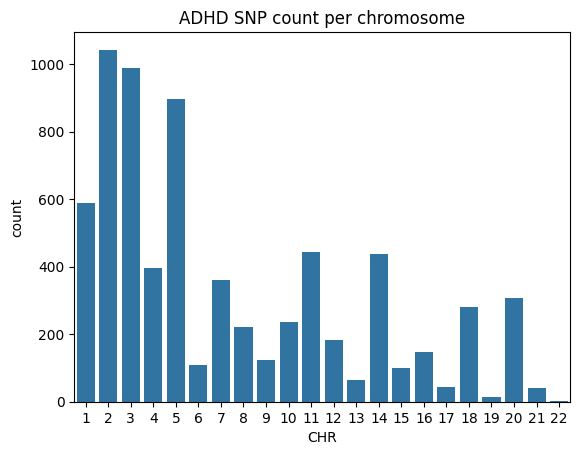

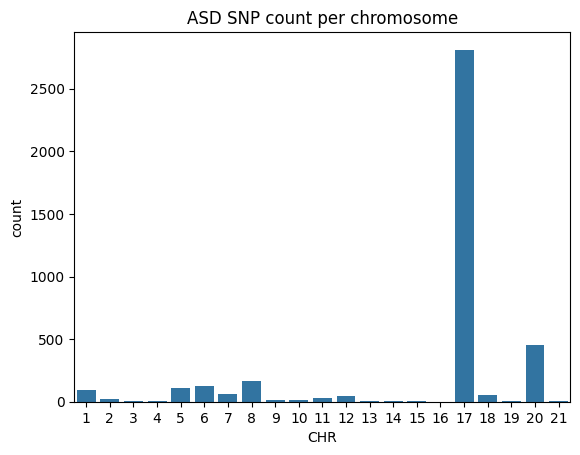

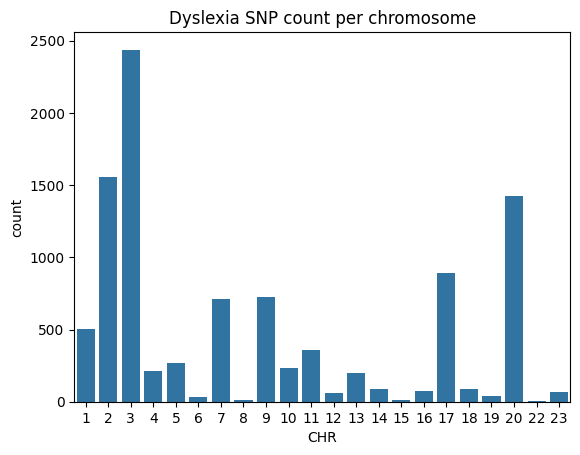

In [27]:
# SNP Count per Chromosome

sns.countplot(data=ADHD_df, x="CHR")
plt.title("ADHD SNP count per chromosome")
plt.show()

sns.countplot(data=ASD_df, x="CHR")
plt.title("ASD SNP count per chromosome")
plt.show()

sns.countplot(data=dys_df, x="CHR")
plt.title("Dyslexia SNP count per chromosome")
plt.show()

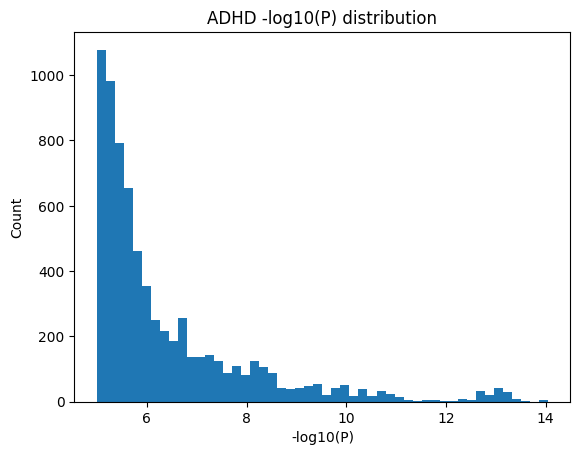

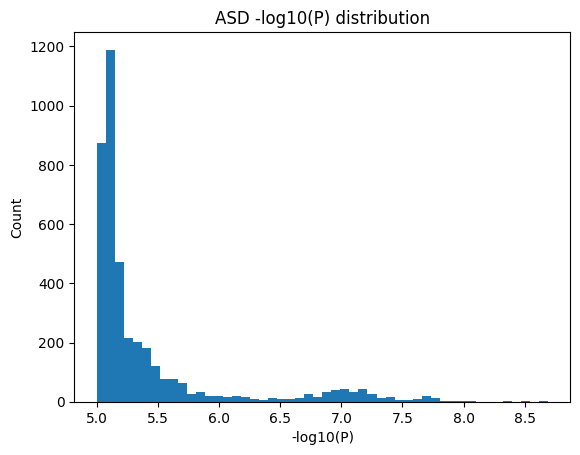

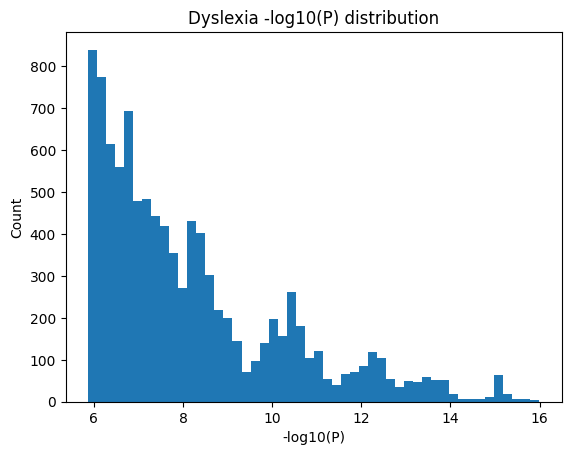

In [28]:
# P-value Distribution

plt.hist(-np.log10(ADHD_df['P']), bins=50)
plt.title("ADHD -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

plt.hist(-np.log10(ASD_df['P']), bins=50)
plt.title("ASD -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

plt.hist(-np.log10(dys_df['P']), bins=50)
plt.title("Dyslexia -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

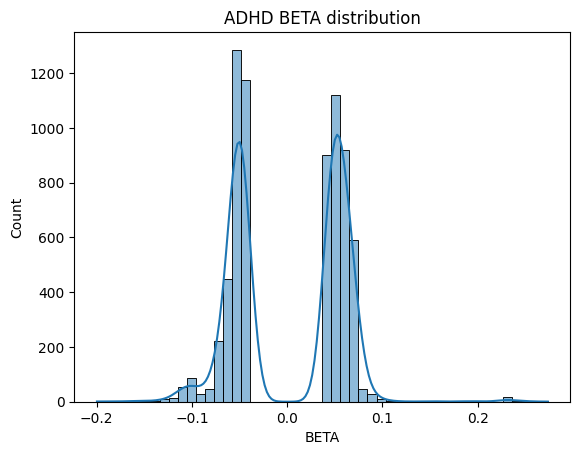

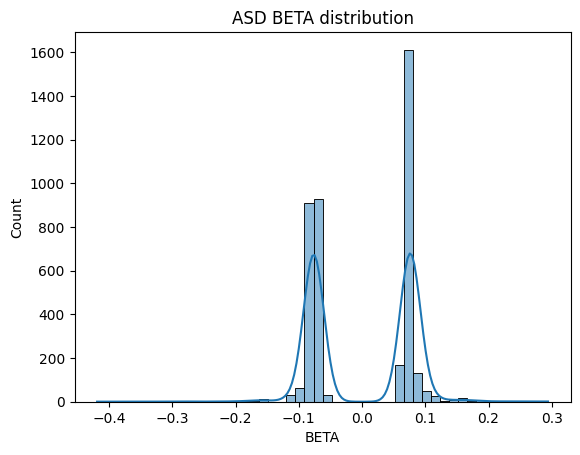

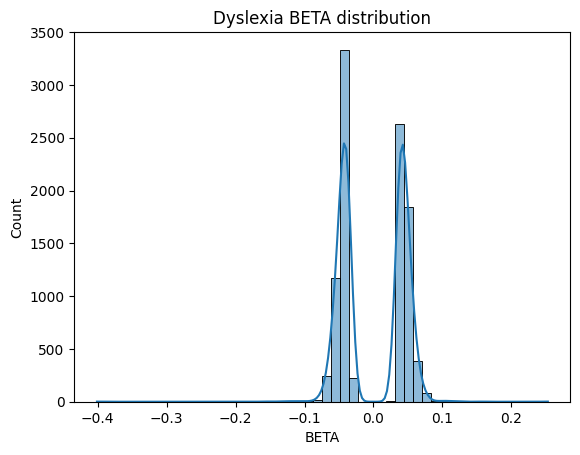

In [29]:
# Beta Distribution
sns.histplot(ADHD_df['BETA'], bins=50, kde=True)
plt.title("ADHD BETA distribution")
plt.show()

sns.histplot(ASD_df['BETA'], bins=50, kde=True)
plt.title("ASD BETA distribution")
plt.show()

sns.histplot(dys_df['BETA'], bins=50, kde=True)
plt.title("Dyslexia BETA distribution")
plt.show()

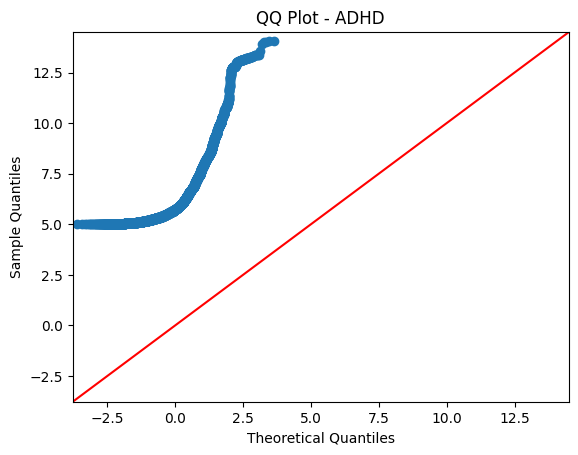

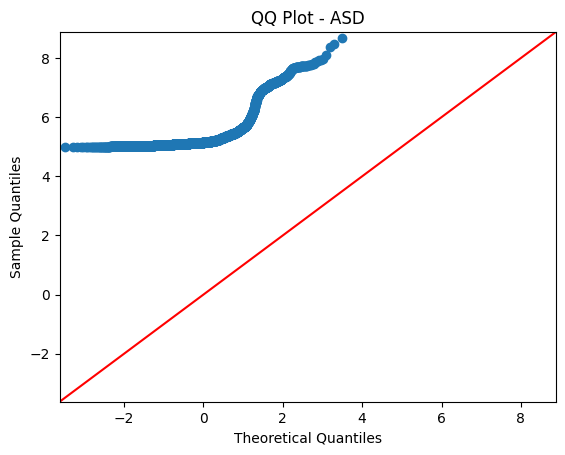

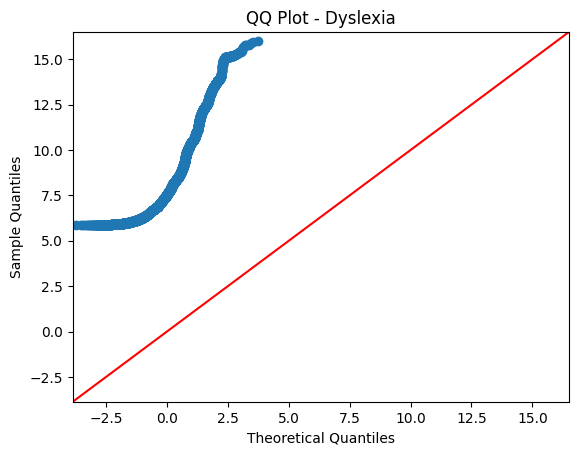

In [30]:
#QQ-Plot (Compare expected vs observed p-values)

from statsmodels.graphics.gofplots import qqplot


qqplot(-np.log10(ADHD_df["P"]), line="45")
plt.title("QQ Plot - ADHD")
plt.show()

qqplot(-np.log10(ASD_df["P"]), line="45")
plt.title("QQ Plot - ASD")
plt.show()

qqplot(-np.log10(dys_df["P"]), line="45")
plt.title("QQ Plot - Dyslexia")
plt.show()

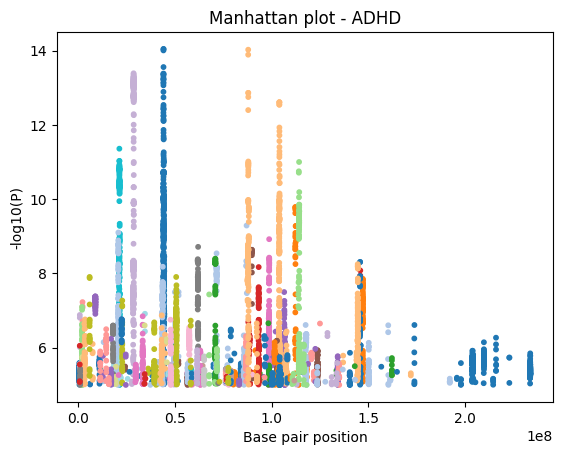

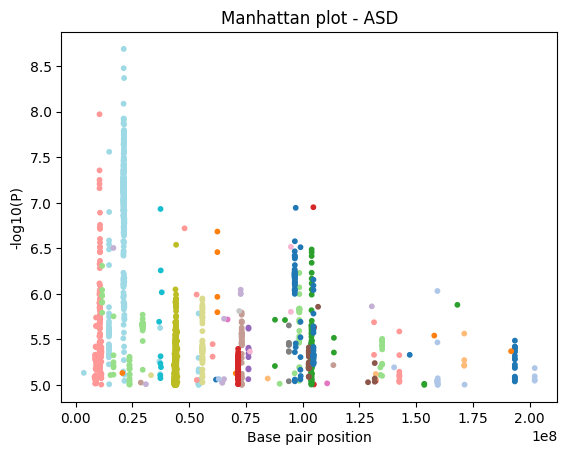

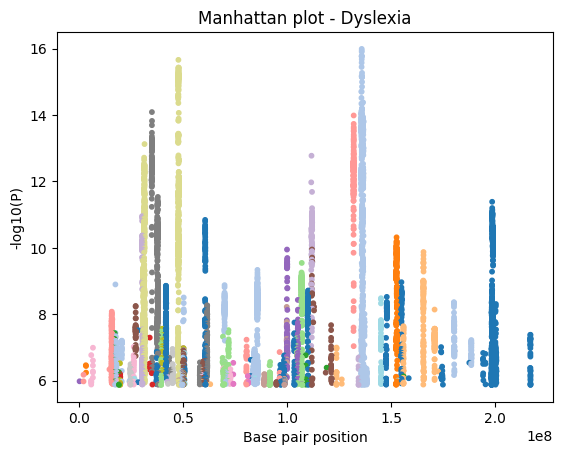

In [31]:
#Manhattan Plot (For a visual overview of SNP significance across the genome)

ADHD_df['-log10P'] = -np.log10(ADHD_df['P'])
plt.scatter(ADHD_df['BP'], ADHD_df['-log10P'], c=ADHD_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - ADHD")
plt.show()

ASD_df['-log10P'] = -np.log10(ASD_df['P'])
plt.scatter(ASD_df['BP'], ASD_df['-log10P'], c=ASD_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - ASD")
plt.show()

dys_df['-log10P'] = -np.log10(dys_df['P'])
plt.scatter(dys_df['BP'], dys_df['-log10P'], c=dys_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - Dyslexia")
plt.show()

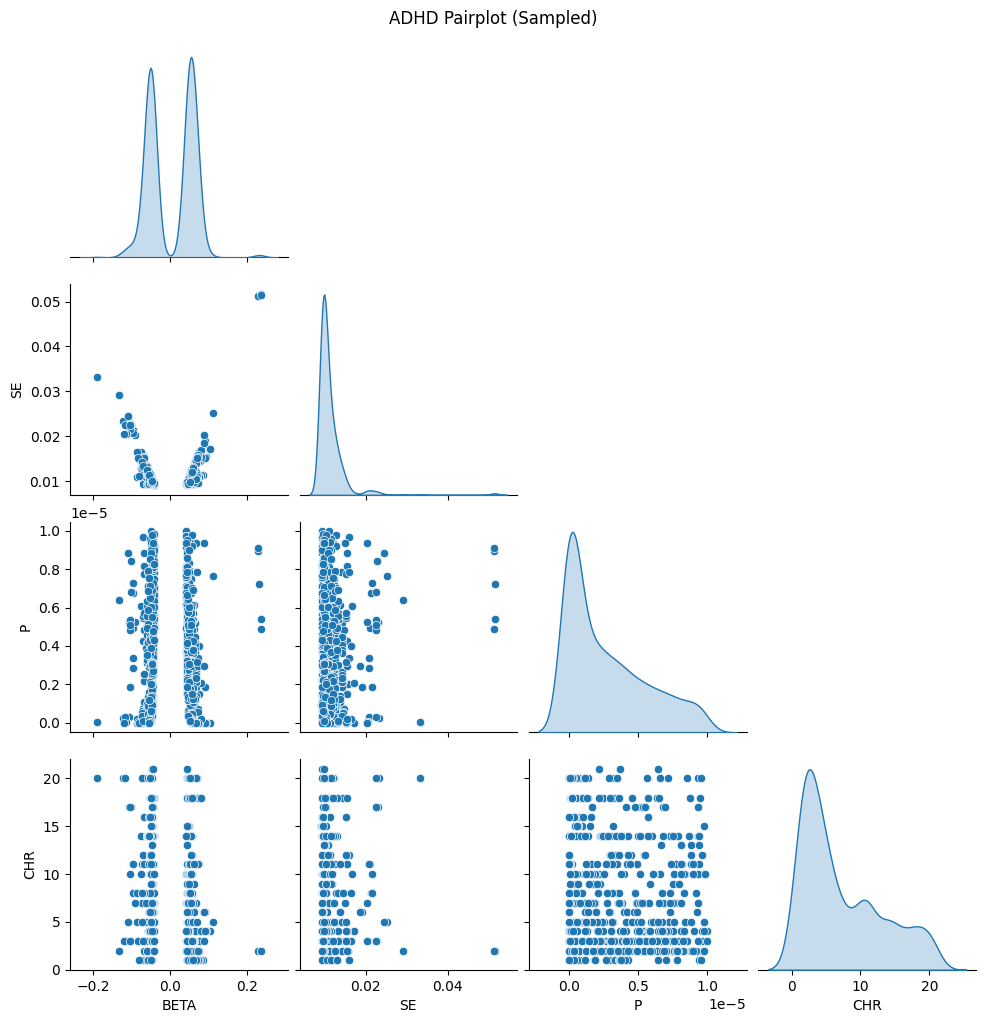

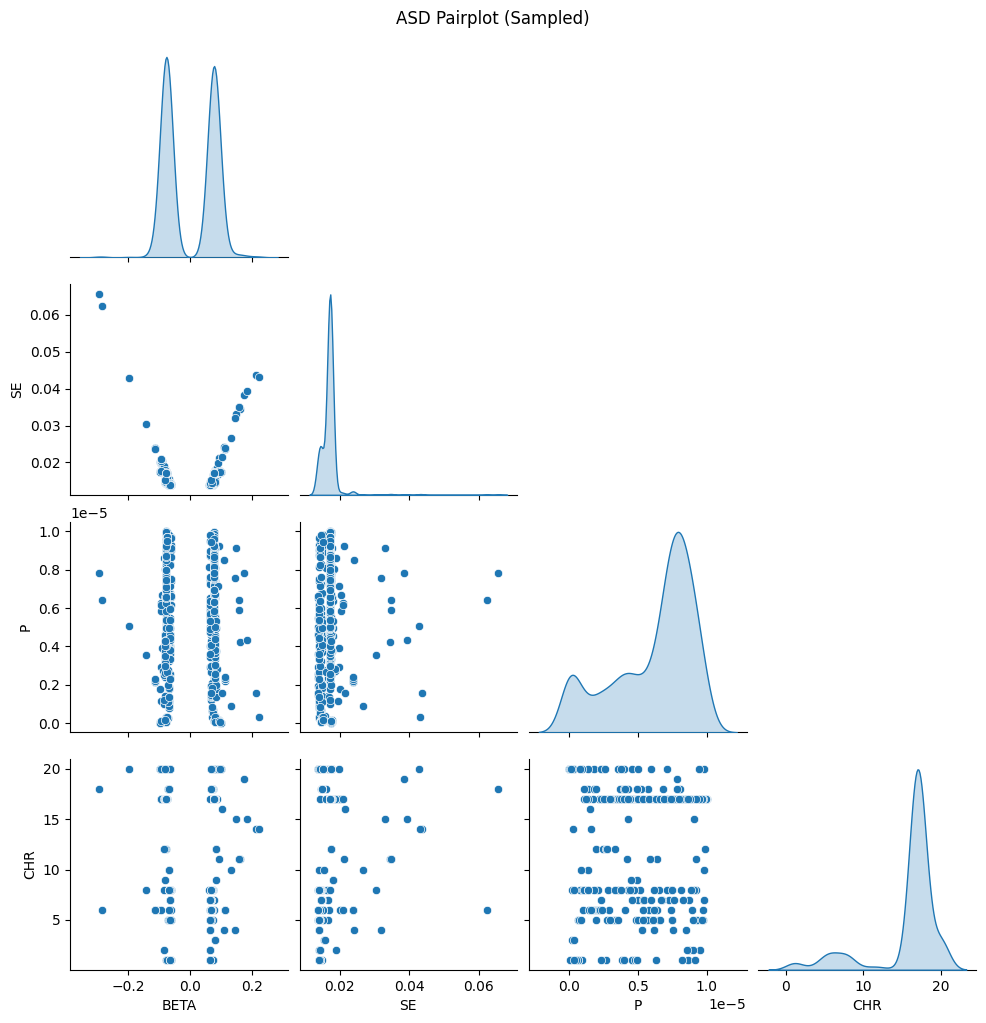

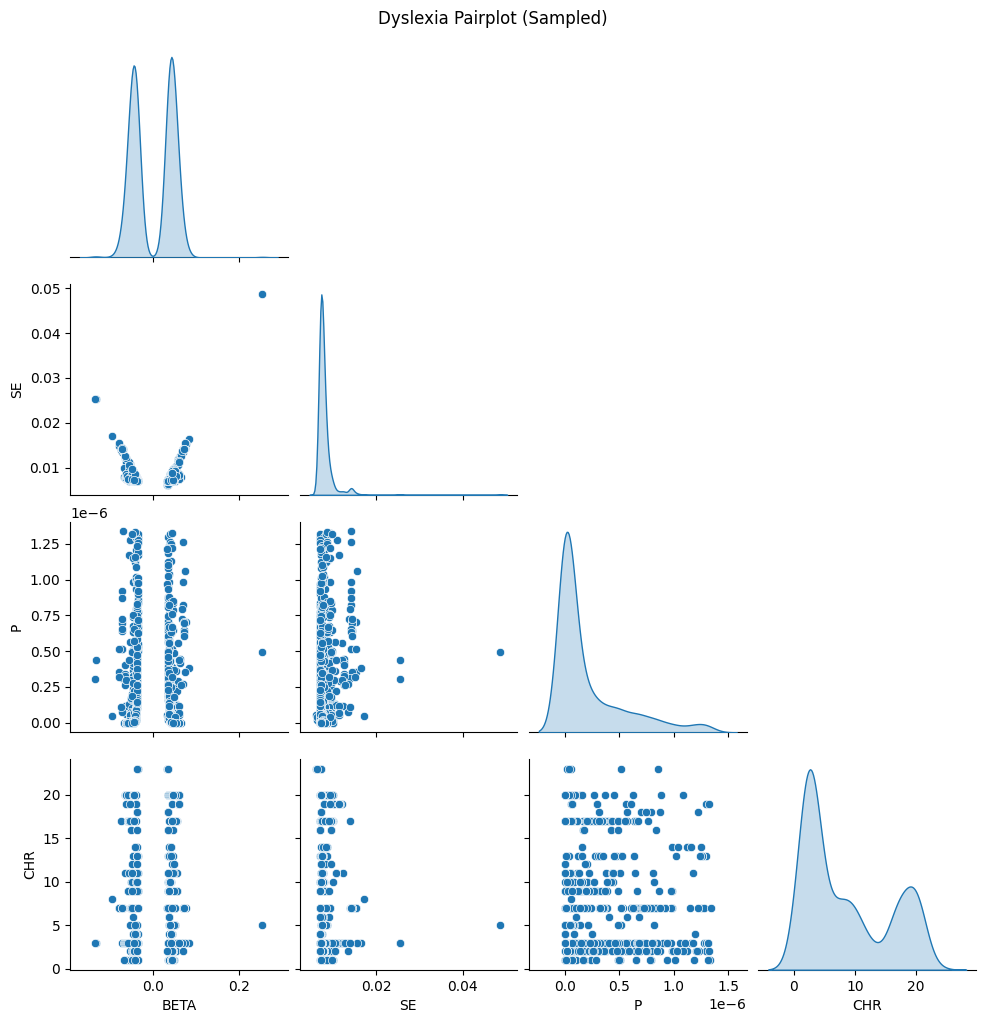

In [32]:
# Pair Plots

adhd_sample = ADHD_df.sample(n=1000, random_state=42)

sns.pairplot(
    adhd_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("ADHD Pairplot (Sampled)", y=1.02)
plt.show()

asd_sample = ASD_df.sample(n=1000, random_state=42)

sns.pairplot(
    asd_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("ASD Pairplot (Sampled)", y=1.02)
plt.show()

dys_sample = dys_df.sample(n=1000, random_state=42)

sns.pairplot(
    dys_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("Dyslexia Pairplot (Sampled)", y=1.02)
plt.show()

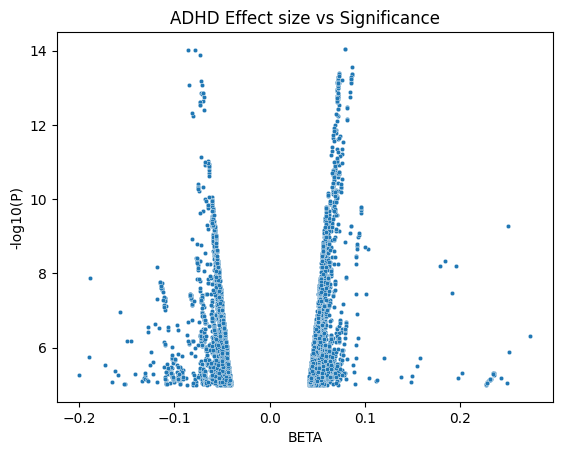

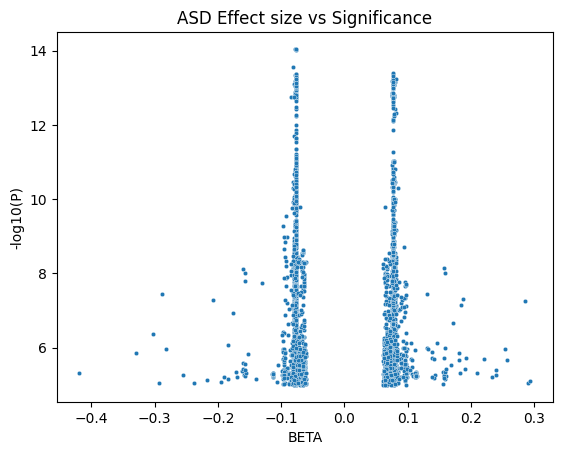

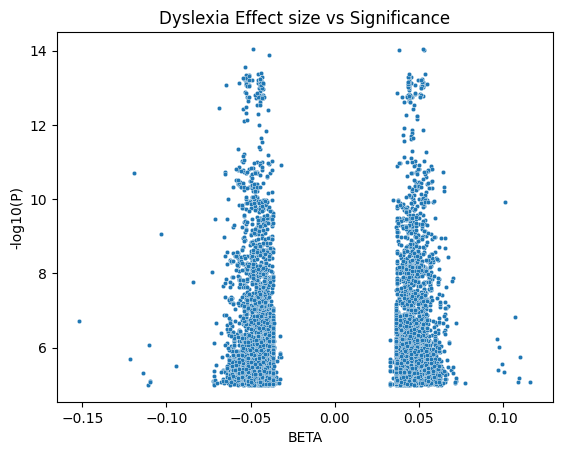

In [33]:
# Effect size vs significance

sns.scatterplot(
    x=ADHD_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("ADHD Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()

sns.scatterplot(
    x=ASD_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("ASD Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()

sns.scatterplot(
    x=dys_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("Dyslexia Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()


### Filter the top 10k SNP

In [34]:
TOP_K = 10_000

ADHD_df = ADHD_df.sort_values("P").head(TOP_K)
ADHD_df = ADHD_df.reset_index(drop=True)

ASD_df = ASD_df.sort_values("P").head(TOP_K)
ASD_df = ASD_df.reset_index(drop=True)


In [35]:
ADHD_df = ADHD_df.drop_duplicates(subset="SNP")
ASD_df = ASD_df.drop_duplicates(subset="SNP")
dys_df = dys_df.drop_duplicates(subset="SNP")

In [36]:
print("ADHD_df shape: ", ADHD_df.shape)
print("ASD_df shape: ", ASD_df.shape)
print("Dyslexia_df shape: ", dys_df.shape)

ADHD_df shape:  (7036, 10)
ASD_df shape:  (4028, 10)
Dyslexia_df shape:  (10000, 10)


### Standardizing and Scalling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
ADHD_df["BETA_scaled"] = scaler.fit_transform(ADHD_df[["BETA"]])
ASD_df["BETA_scaled"] = scaler.fit_transform(ASD_df[["BETA"]])
dys_df["BETA_scaled"] = scaler.fit_transform(dys_df[["BETA"]])

### Save to CSV

In [38]:
ADHD_df.to_csv("ADHD_top10k_clean.csv", index=False)
ASD_df.to_csv("ASD_top10k_clean.csv", index=False)
dys_df.to_csv("Dyslexia_top10k_clean.csv", index=False)